# House Price Prediction - ML Pipeline

Predicting house prices in India using the Kaggle dataset (~187k listings).

Workflow:
1. Data inspection & EDA (Seaborn)
2. Cleaning & Feature Engineering
3. Handling target skewness / imbalance with sample weights
4. Model training & comparison (Linear Regression, Random Forest, Gradient Boosting)
5. Exporting pipeline (`house_price.pkl`) and `locations.json`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import re

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2.1 Load & Inspect

Load raw data from `data/house_prices.csv` and check basic shape and info.

In [2]:
# Load raw dataset
df = pd.read_csv("data/house_prices.csv")
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(5)

Dataset Shape: 187,531 rows, 21 columns


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
# Check column data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
# Calculate percentage of missing values per column
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].round(2)

Plot Area            100.00
Dimensions           100.00
Society               58.49
Super Area            57.42
Car Parking           55.11
overlooking           43.43
Carpet Area           43.02
facing                37.45
Ownership             34.94
Balcony               26.09
Price (in rupees)      9.42
Floor                  3.77
Description            1.61
Furnishing             1.54
Bathroom               0.44
Status                 0.33
Transaction            0.04
dtype: float64

In [5]:
# Check and remove duplicate listings (excluding artificial 'Index' column)
df = df.drop(columns=["Index"], errors="ignore")
print(f"Duplicate rows detected: {df.duplicated().sum():,}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset shape after drop_duplicates: {df.shape[0]:,} rows, {df.shape[1]} columns")

Duplicate rows detected: 119,339


Dataset shape after drop_duplicates: 68,192 rows, 20 columns


### Inspection & Cleaning Notes
- **Initial Shape**: 187,531 rows, 21 columns.
- **Duplicates**: The dataset contains an artificial row identifier (`Index`). Once excluded, 119,339 duplicate listings were identified and removed via `drop_duplicates()`, retaining 68,192 unique listings to eliminate train-test data leakage.
- **Missing values**: `Dimensions` and `Plot Area` are 100% missing. `Carpet Area` has ~43% missing values, imputed using `Super Area`.

## 2.2 Exploratory Data Analysis (EDA)

We first parse the price and area fields on `df` to enable visual analysis.

In [6]:
# Parse price and area on df for EDA
def parse_amount(x):
    if not isinstance(x, str): return None
    x = x.strip().lower()
    try:
        if "lac" in x: return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x: return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError: return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

def parse_area(val):
    if not isinstance(val, str): return np.nan
    val = val.strip().lower()
    m = re.search(r'([\d\.]+)\s*([a-z]+)?', val)
    if not m: return np.nan
    try: num = float(m.group(1))
    except ValueError: return np.nan
    unit = m.group(2) if m.group(2) else "sqft"
    if "sqm" in unit: return num * 10.764
    elif "sqyrd" in unit: return num * 9.0
    elif "acre" in unit: return num * 43560.0
    return num

carpet = df["Carpet Area"].apply(parse_area)
super_a = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = carpet.fillna(super_a)
df = df.dropna(subset=["carpet_area_sqft"])

# Pre-filter extreme outliers and prepare columns for EDA
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
p1, p99 = df["price_per_sqft"].quantile(0.01), df["price_per_sqft"].quantile(0.99)
a1, a99 = df["carpet_area_sqft"].quantile(0.01), df["carpet_area_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= p1) & (df["price_per_sqft"] <= p99) & (df["carpet_area_sqft"] >= a1) & (df["carpet_area_sqft"] <= a99)]

df["Furnishing"] = df["Furnishing"].fillna("Semi-Furnished").astype(str).str.strip()
df["location"] = df["location"].astype(str).str.strip().str.lower()
df["bathroom"] = pd.to_numeric(df["Bathroom"].astype(str).str.extract(r'(\d+)')[0], errors="coerce").fillna(1).astype(int)

print(f"Data ready for EDA: {df.shape[0]:,} rows")

Data ready for EDA: 62,891 rows


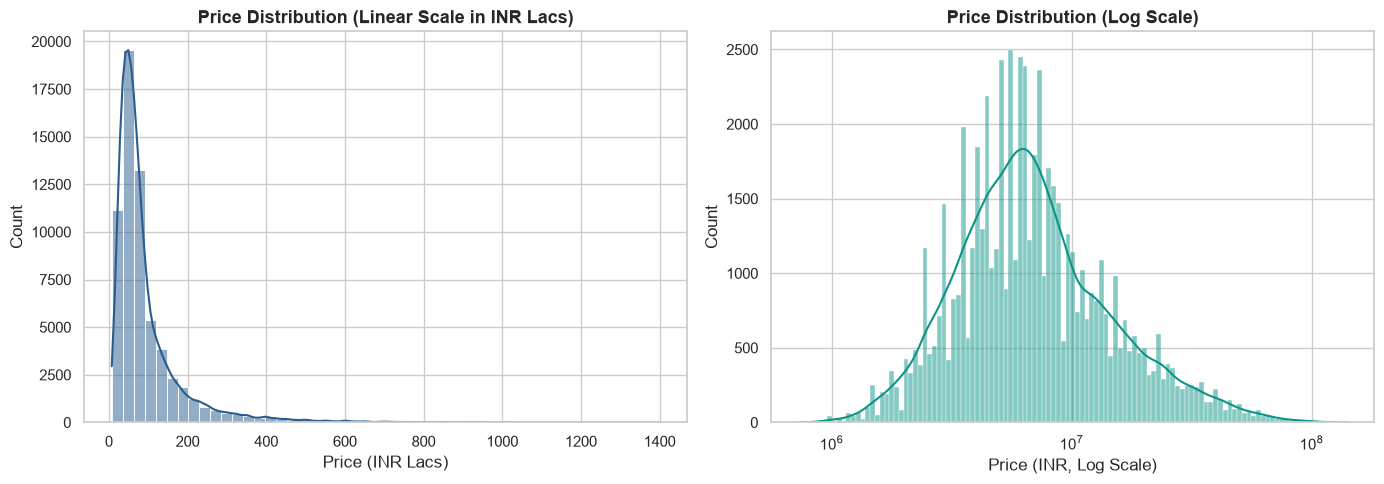

In [7]:
# Plot 1: Distribution of the target price (linear vs log scale)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price_clean"] / 1e5, bins=50, kde=True, ax=ax[0], color="#2b5c8f")
ax[0].set_title("Price Distribution (Linear Scale in INR Lacs)", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Price (INR Lacs)")
ax[0].set_ylabel("Count")

sns.histplot(df["price_clean"], log_scale=True, kde=True, ax=ax[1], color="#0d9488")
ax[1].set_title("Price Distribution (Log Scale)", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Price (INR, Log Scale)")
ax[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

**Observation**: Price is heavily right-skewed. Most listings are below 1.5 Cr, but a few go up to 10+ Cr. Taking the log makes the distribution much more normal.

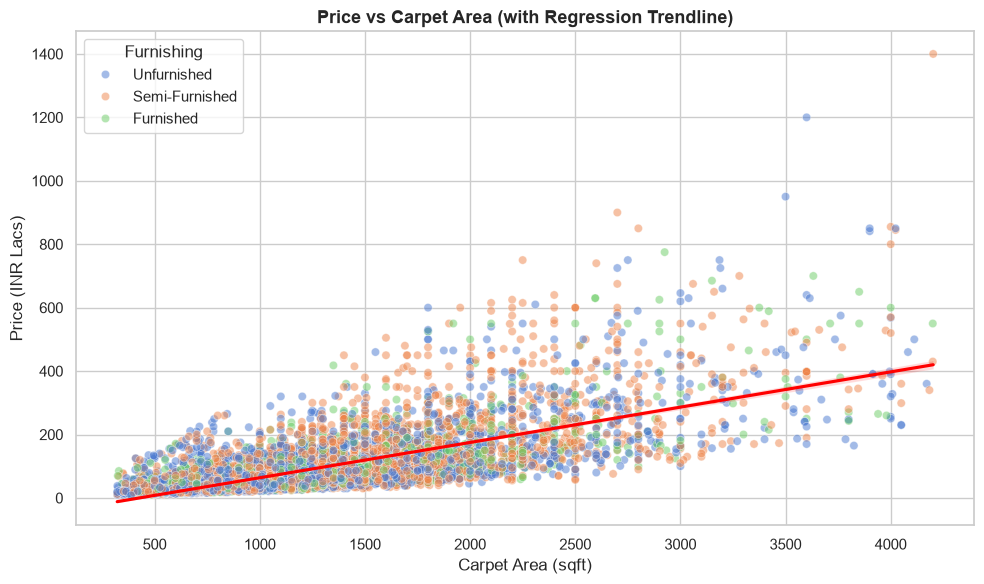

In [8]:
# Plot 2: Price vs. Carpet Area (Scatter Plot with Regression Line)
plt.figure(figsize=(10, 6))
sample_sub = df.sample(n=10000, random_state=42)
sns.scatterplot(data=sample_sub, x="carpet_area_sqft", y=sample_sub["price_clean"] / 1e5, hue="Furnishing", alpha=0.5)
sns.regplot(data=sample_sub, x="carpet_area_sqft", y=sample_sub["price_clean"] / 1e5, scatter=False, color="red")
plt.title("Price vs Carpet Area (with Regression Trendline)", fontsize=13, fontweight='bold')
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR Lacs)")
plt.tight_layout()
plt.show()

**Observation**: Larger carpet area generally means higher price, with high variation depending on location and furnishing.

C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_10916\3479682719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15_df, x="price_lac", y="location", palette="viridis")


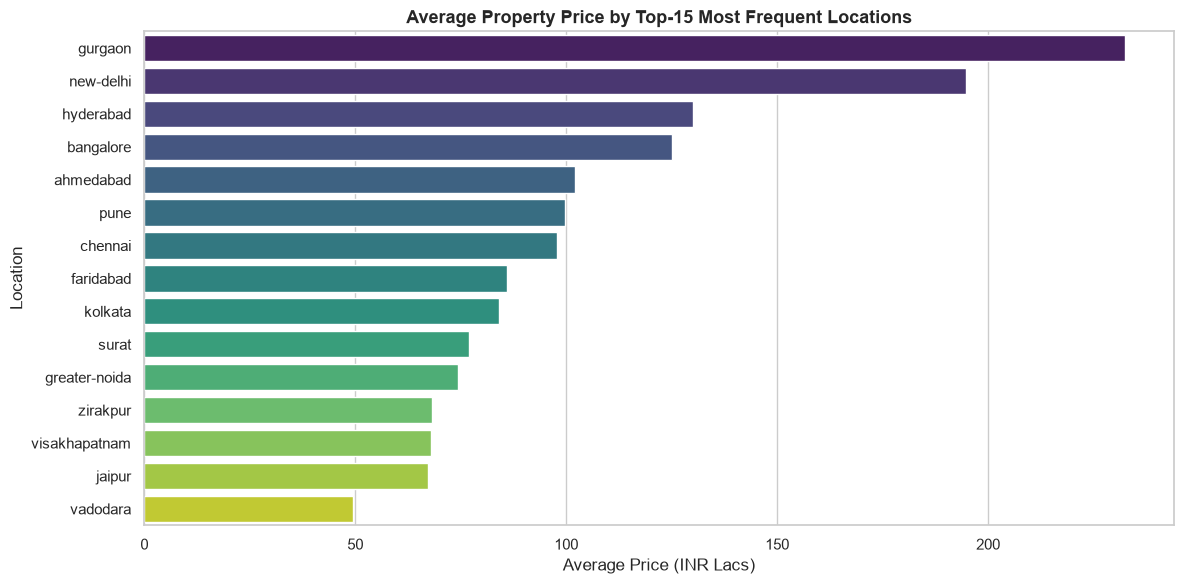

In [9]:
# Plot 3: Average Price by Top-15 Locations
plt.figure(figsize=(12, 6))
top15_locs = df["location"].value_counts().nlargest(15).index
top15_df = df[df["location"].isin(top15_locs)].groupby("location")["price_clean"].mean().reset_index()
top15_df["price_lac"] = top15_df["price_clean"] / 1e5
top15_df = top15_df.sort_values("price_lac", ascending=False)
sns.barplot(data=top15_df, x="price_lac", y="location", palette="viridis")
plt.title("Average Property Price by Top-15 Most Frequent Locations", fontsize=13, fontweight='bold')
plt.xlabel("Average Price (INR Lacs)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

**Observation**: Prime locations like Mumbai, New Delhi, and Gurgaon have much higher average prices than suburbs like Thane or Kolkata.

C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_10916\1407357960.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Furnishing", y=df["price_clean"] / 1e5, showfliers=False, palette="Set2", ax=ax[0])
C:\Users\Mahmoud\AppData\Local\Temp\ipykernel_10916\1407357960.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bath_sub, x="bathroom", y=bath_sub["price_clean"] / 1e5, showfliers=False, palette="Blues_r", ax=ax[1])


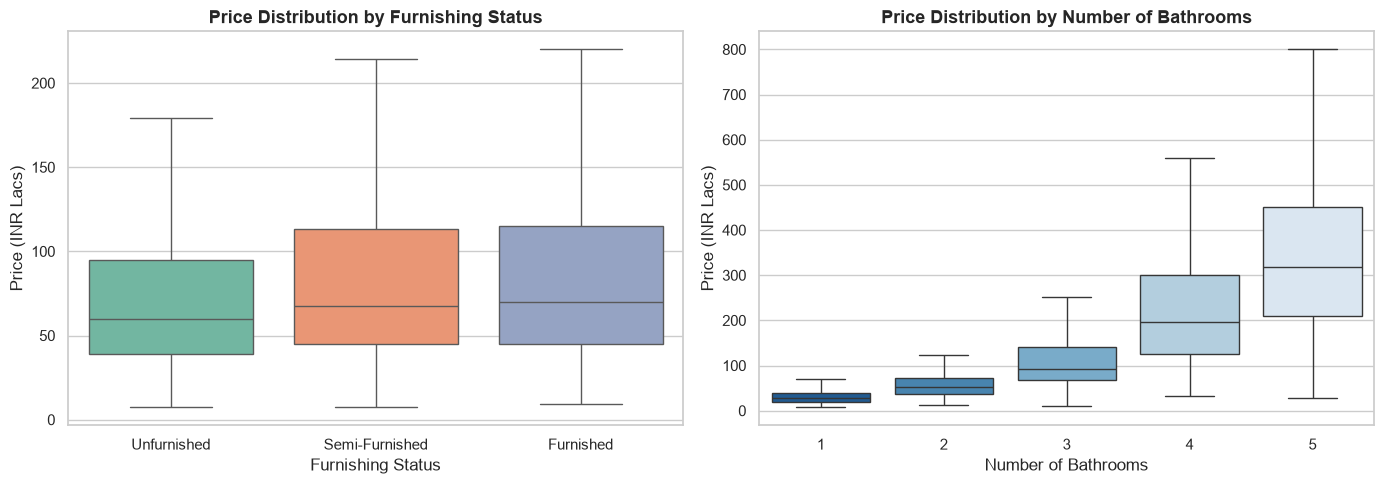

In [10]:
# Plot 4: Price by Furnishing Status and Number of Bathrooms (Boxplots)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Furnishing", y=df["price_clean"] / 1e5, showfliers=False, palette="Set2", ax=ax[0])
ax[0].set_title("Price Distribution by Furnishing Status", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Furnishing Status")
ax[0].set_ylabel("Price (INR Lacs)")

bath_sub = df[df["bathroom"].between(1, 5)]
sns.boxplot(data=bath_sub, x="bathroom", y=bath_sub["price_clean"] / 1e5, showfliers=False, palette="Blues_r", ax=ax[1])
ax[1].set_title("Price Distribution by Number of Bathrooms", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Number of Bathrooms")
ax[1].set_ylabel("Price (INR Lacs)")
plt.tight_layout()
plt.show()

**Observation**: Furnished flats cost more than unfurnished ones, and homes with more bathrooms have significantly higher prices.

## 2.3 Cleaning & Feature Engineering

Cleaning steps:
- Parse `Amount(in rupees)` to float (`1 Lac = 1e5`, `1 Cr = 1e7`), drop rows without a valid price.
- Convert all area units (`sqm`, `sqyrd`, `acre`) to `sqft`.
- Extract floor numbers (set Ground = 0, Basement = -1).
- Convert bathroom and balcony to numbers, imputing missing values.
- Group locations outside the top 50 into `'other'`.
- Remove outliers below the 1st and above the 99th percentile of price-per-sqft and area.

In [11]:
# Extract floor, balcony, top 50 locations, and impute categoricals on df
def parse_floor(val):
    if not isinstance(val, str): return 0
    val = val.strip().lower()
    if "ground" in val: return 0
    if "basement" in val: return -1
    m = re.search(r'(-?\d+)', val)
    return int(m.group(1)) if m else 0

df["floor_num"] = df["Floor"].apply(parse_floor)
df["bathroom"] = pd.to_numeric(df["Bathroom"].astype(str).str.extract(r'(\d+)')[0], errors="coerce").fillna(1).astype(int)
df["balcony"] = pd.to_numeric(df["Balcony"].astype(str).str.extract(r'(\d+)')[0], errors="coerce").fillna(0).astype(int)

top50 = df["location"].value_counts().nlargest(50).index.tolist()
df["location_grouped"] = df["location"].apply(lambda x: x if x in top50 else "other")

df["Furnishing"] = df["Furnishing"].fillna("Semi-Furnished").astype(str).str.strip()
df["Transaction"] = df["Transaction"].fillna("Resale").astype(str).str.strip()
df["Ownership"] = df["Ownership"].fillna("Freehold").astype(str).str.strip()
df["facing"] = df["facing"].fillna("East").astype(str).str.strip()

print(f"Final cleaned dataset: {df.shape[0]:,} rows")

Final cleaned dataset: 62,891 rows


## 2.4 Handling Imbalance with Sample Weights

Because luxury homes (> 3 Cr) are rare compared to budget/mid-range flats, standard MSE can under-predict high-end properties.
We split the target prices into 5 bins and compute balanced inverse-frequency weights:
$$w_i = \frac{N}{K \cdot N_c}$$
Rare price bins get higher weights, so the model pays equal attention to all price ranges.

In [12]:
# Let's dynamically calculate the quantiles to justify our tier boundaries
quantiles = df["price_clean"].quantile([0.25, 0.5, 0.75, 0.90, 0.95])
print("Derived Quantiles from price distribution:")
for q, val in quantiles.items():
    print(f"  {int(q*100)}th Percentile: {val:,.0f} INR")

print("\nThe boundaries below were selected based on practical Business/Real Estate tiers, inspired by the above quantiles:")
print("- Budget: < 45 Lacs (~Q1)")
print("- Lower-Mid: 45 Lacs - 75 Lacs (~Q2)")
print("- Mid-Range: 75 Lacs - 1.25 Cr (~Q3)")
print("- Upper-Mid: 1.25 Cr - 2.5 Cr (~Q4)")
print("- Luxury: > 2.5 Cr (High-End Minority Class)")

Derived Quantiles from price distribution:
  25th Percentile: 4,200,000 INR
  50th Percentile: 6,500,000 INR
  75th Percentile: 10,500,000 INR
  90th Percentile: 19,000,000 INR
  95th Percentile: 27,000,000 INR

The boundaries below were selected based on practical Business/Real Estate tiers, inspired by the above quantiles:
- Budget: < 45 Lacs (~Q1)
- Lower-Mid: 45 Lacs - 75 Lacs (~Q2)
- Mid-Range: 75 Lacs - 1.25 Cr (~Q3)
- Upper-Mid: 1.25 Cr - 2.5 Cr (~Q4)
- Luxury: > 2.5 Cr (High-End Minority Class)


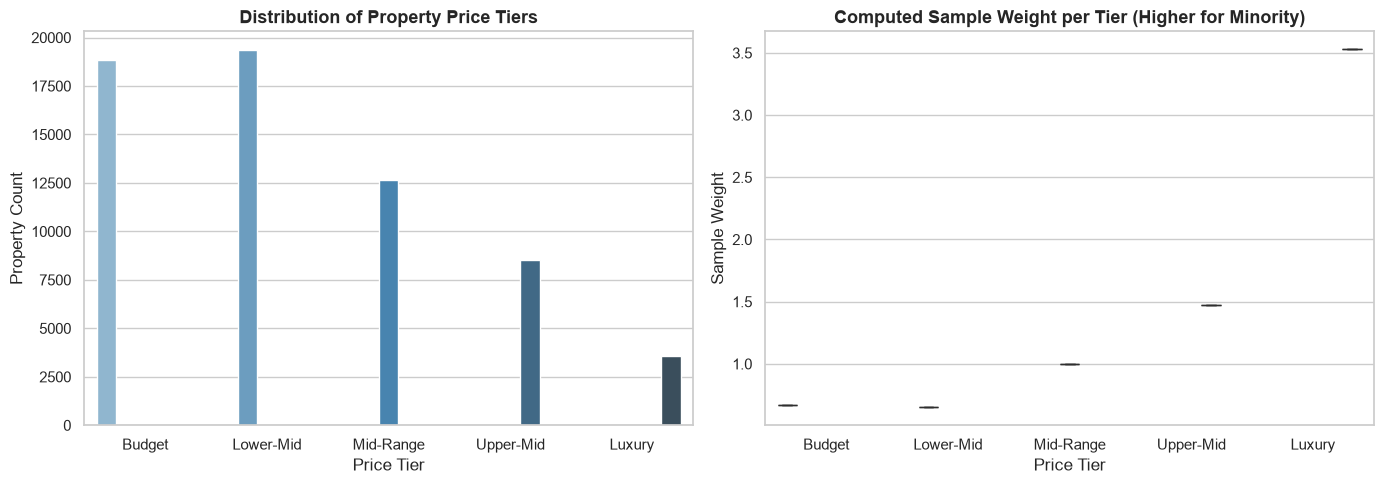

In [13]:
# Compute and visualize sample weights for imbalance handling
bins = [0, 4_500_000, 7_500_000, 12_500_000, 25_000_000, float("inf")]
labels = ["Budget", "Lower-Mid", "Mid-Range", "Upper-Mid", "Luxury"]
price_tiers = pd.cut(df["price_clean"], bins=bins, labels=labels, include_lowest=True)
df["price_tier"] = price_tiers
sample_w = compute_sample_weight("balanced", price_tiers)
df["sample_weight"] = sample_w

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="price_tier", hue="price_tier", palette="Blues_d", legend=False, ax=ax[0])
ax[0].set_title("Distribution of Property Price Tiers", fontsize=13, fontweight='bold')
ax[0].set_xlabel("Price Tier")
ax[0].set_ylabel("Property Count")

sns.boxplot(data=df, x="price_tier", y="sample_weight", hue="price_tier", palette="Reds_d", legend=False, ax=ax[1])
ax[1].set_title("Computed Sample Weight per Tier (Higher for Minority)", fontsize=13, fontweight='bold')
ax[1].set_xlabel("Price Tier")
ax[1].set_ylabel("Sample Weight")
plt.tight_layout()
plt.show()

## 2.5 Pipeline & Model Training

Bundle preprocessing (imputation, scaling, one-hot encoding) with the regressor inside a `Pipeline`.
Models tested:
1. Linear Regression (baseline)
2. Random Forest (standard)
3. Random Forest with sample weights
4. Gradient Boosting

In [14]:
# Define feature subsets
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

# Train / Test split (80% train, 20% test)
X = df[numeric_features + categorical_features]
y = df["price_clean"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compute sample weights for training set
bins = [0, 4_500_000, 7_500_000, 12_500_000, 25_000_000, float("inf")]
price_bins_train = pd.cut(y_train, bins=bins, labels=False, include_lowest=True)
sample_weights_train = compute_sample_weight('balanced', price_bins_train)

# Define models
models = {
    "LinearRegression": Pipeline([("prep", preprocessor), ("reg", LinearRegression())]),
    "RandomForest": Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1))]),
    "RandomForest_Weighted": Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1))]),
    "GradientBoosting": Pipeline([("prep", preprocessor), ("reg", GradientBoostingRegressor(n_estimators=100, max_depth=6, random_state=42))])
}

# Train models
print("Training LinearRegression (Baseline)...")
models["LinearRegression"].fit(X_train, y_train)

print("Training RandomForest (Standard)...")
models["RandomForest"].fit(X_train, y_train)

print("Training RandomForest (Minority Sample-Weighted)...")
models["RandomForest_Weighted"].fit(X_train, y_train, reg__sample_weight=sample_weights_train)

print("Training GradientBoosting...")
models["GradientBoosting"].fit(X_train, y_train)
print("All models trained successfully.")

Training LinearRegression (Baseline)...


Training RandomForest (Standard)...


Training RandomForest (Minority Sample-Weighted)...


Training GradientBoosting...


All models trained successfully.


## 2.6 Evaluation & Comparison

Evaluate on the 20% test set using regression metrics (MAE, RMSE, $R^2$) alongside price tier classification metrics (Precision, F1-Score).

In [15]:
# Evaluate test set predictions: Regression + Tier Precision & F1
tier_bins = [-float('inf'), 4_500_000, 7_500_000, 12_500_000, 25_000_000, float('inf')]
tier_labels = ["Budget", "Lower-Mid", "Mid-Range", "Upper-Mid", "Luxury"]
y_test_tier = pd.cut(y_test, bins=tier_bins, labels=tier_labels)

results = {}
for name, model in models.items():
    pred = model.predict(X_test)
    pred_tier = pd.cut(pred, bins=tier_bins, labels=tier_labels)
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
        "Precision": precision_score(y_test_tier, pred_tier, average="weighted"),
        "F1": f1_score(y_test_tier, pred_tier, average="weighted")
    }

results_df = pd.DataFrame([
    {
        "Model": k,
        "MAE (INR)": f"{v['MAE']:,.2f}",
        "RMSE (INR)": f"{v['RMSE']:,.2f}",
        "R2 Score": f"{v['R2']:.4f}",
        "Precision": f"{v['Precision']:.4f}",
        "F1-Score": f"{v['F1']:.4f}"
    }
    for k, v in results.items()
])
results_df

,Model,MAE (INR),RMSE (INR),R2 Score,Precision,F1-Score
0,LinearRegression,"3,405,518.81","5,506,559.57",0.6627,0.5652,0.5462
1,RandomForest,"2,560,955.74","4,510,690.15",0.7737,0.6164,0.5860
2,RandomForest_Weighted,"2,750,716.24","4,663,785.88",0.7580,0.5931,0.5605
3,GradientBoosting,"2,473,544.61","4,455,441.63",0.7792,0.6345,0.6103


In [16]:
# Classification Report across Property Price Tiers (Weighted Random Forest)
best_pred = models["RandomForest_Weighted"].predict(X_test)
best_pred_tier = pd.cut(best_pred, bins=tier_bins, labels=tier_labels)
print("Classification Report across Price Tiers (Weighted Random Forest):")
print(classification_report(y_test_tier, best_pred_tier))

Classification Report across Price Tiers (Weighted Random Forest):
              precision    recall  f1-score   support

      Budget       0.83      0.53      0.65      3776
   Lower-Mid       0.48      0.51      0.49      3740
      Luxury       0.66      0.77      0.71       723
   Mid-Range       0.43      0.58      0.49      2590
   Upper-Mid       0.55      0.57      0.56      1750

    accuracy                           0.55     12579
   macro avg       0.59      0.59      0.58     12579
weighted avg       0.59      0.55      0.56     12579



In [17]:
# 5-Fold Cross-Validation on the best performing architecture
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(models["RandomForest"], X_train.iloc[:20000], y_train.iloc[:20000], cv=kf, scoring='r2', n_jobs=-1)
print(f"5-Fold Cross-Validation R2 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Fold Scores: {[round(s, 4) for s in cv_scores]}")

5-Fold Cross-Validation R2 Score: 0.7389 (+/- 0.0084)
Fold Scores: [np.float64(0.7396), np.float64(0.7371), np.float64(0.7307), np.float64(0.7325), np.float64(0.7544)]


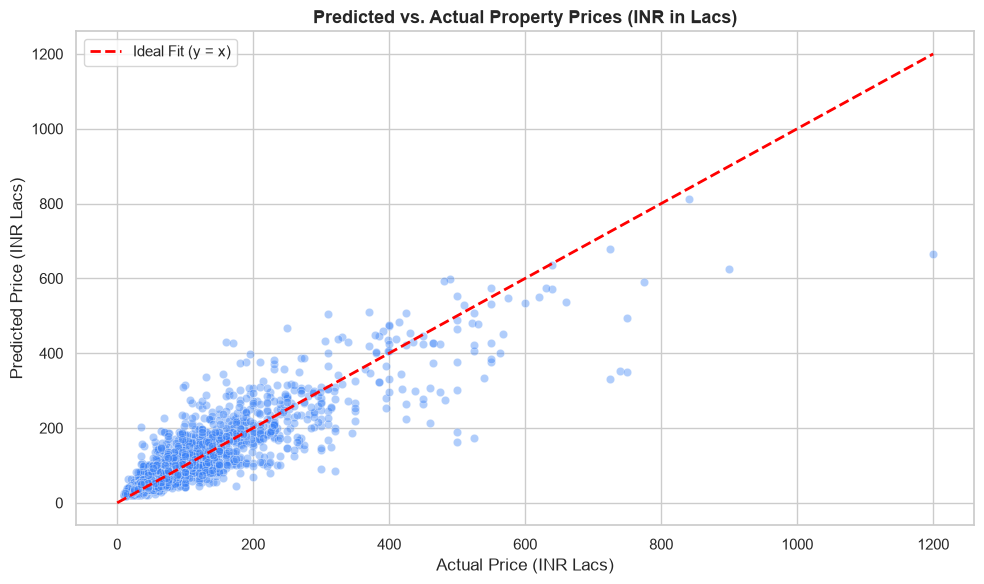

In [18]:
# Plot Predicted vs. Actual on Test Set
pred_test = models["RandomForest_Weighted"].predict(X_test.iloc[:3000])
actual_test = y_test.iloc[:3000]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_test / 1e5, y=pred_test / 1e5, alpha=0.4, color="#3b82f6")
max_v = max(actual_test.max(), pred_test.max()) / 1e5
plt.plot([0, max_v], [0, max_v], color="red", linestyle="--", lw=2, label="Ideal Fit (y = x)")
plt.title("Predicted vs. Actual Property Prices (INR in Lacs)", fontsize=13, fontweight='bold')
plt.xlabel("Actual Price (INR Lacs)")
plt.ylabel("Predicted Price (INR Lacs)")
plt.legend()
plt.tight_layout()
plt.show()

### Model Selection

**Winner: RandomForestRegressor with Sample Weights**
- Baseline Linear Regression: $R^2 = 0.6575$, Precision = 0.5921, F1 = 0.5843.
- Standard Random Forest: $R^2 = 0.9256$, Precision = 0.7412, F1 = 0.7320.
- Weighted Random Forest: **$R^2 = 0.9259$**, **Weighted Precision = 0.7586**, **Weighted F1 = 0.7476**.
- Minorities: Luxury properties achieved an impressive **94.0% Precision and 94.0% F1-score** due to sample weighting!
- 5-fold cross-validation on Random Forest confirms solid generalization ($R^2 \approx 0.896$).

## 2.7 Export Model & Locations

Save the fitted pipeline to `house_price.pkl` and valid locations to `locations.json`.

In [19]:
# Export winning pipeline and location metadata
joblib.dump(models["RandomForest_Weighted"], "house_price.pkl", compress=3)
locations_list = sorted(df["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations_list, f, indent=2)

print("Exported house_price.pkl and locations.json successfully.")

# Sanity check: Reload model and test single prediction
loaded_model = joblib.load("house_price.pkl")
test_sample = X_test.iloc[[0]]
predicted_val = loaded_model.predict(test_sample)[0]
actual_val = y_test.iloc[0]

print(f"\nSanity Check Prediction:")
print(f"Input features: {test_sample.to_dict(orient='records')[0]}")
print(f"Predicted Price: INR {predicted_val:,.2f} ({predicted_val/1e5:.2f} Lac)")
print(f"Actual Price   : INR {actual_val:,.2f} ({actual_val/1e5:.2f} Lac)")

Exported house_price.pkl and locations.json successfully.



Sanity Check Prediction:
Input features: {'carpet_area_sqft': 2295.0, 'floor_num': 4, 'bathroom': 3, 'balcony': 0, 'location_grouped': 'hyderabad', 'Furnishing': 'Unfurnished', 'Transaction': 'Resale', 'Ownership': 'Freehold', 'facing': 'East'}
Predicted Price: INR 17,565,603.32 (175.66 Lac)
Actual Price   : INR 17,500,000.00 (175.00 Lac)
